## Cравнение трёх моделей оценки цены недвижимости

## 1. Импорт библиотек

In [19]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost не установлен. Для загрузки модели выполните: python -m pip install catboost")

## 2. Пути к данным, моделям и отчётам

In [20]:
DATA_DIR = Path("../data/modeling")
MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")

## 3. Загружаем test-выборку и список признаков

In [21]:
test_df = pd.read_csv(DATA_DIR / "moscow_test.csv")

with open(DATA_DIR / "feature_columns.json", "r", encoding="utf-8") as f:
    features = json.load(f)

with open(DATA_DIR / "target_column.json", "r", encoding="utf-8") as f:
    target_info = json.load(f)

TARGET = target_info["target"]

X_test = test_df[features].copy()
y_test = test_df[TARGET].copy()
categorical_features = X_test.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

X_test_catboost = X_test.copy()

for col in categorical_features:
    X_test_catboost[col] = X_test_catboost[col].astype("object")
    X_test_catboost[col] = X_test_catboost[col].where(X_test_catboost[col].notna(), "missing")
    X_test_catboost[col] = X_test_catboost[col].astype(str)

X_test.head()

C:\Users\tikho\AppData\Local\Temp\ipykernel_10760\2171208132.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_test.select_dtypes(


,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,Secondary,Ботанический сад,16.0,2.0,51.0,36.0,8.0,17.0,17.0,Without renovation
1,Secondary,Белорусская,16.0,3.0,70.0,52.0,17.0,5.0,6.0,Designer
2,Secondary,Третьяковская,6.0,4.0,121.0,14.9,16.7,3.0,7.0,Designer
3,Secondary,Давыдково,22.0,0.0,30.0,17.3,9.1,10.0,30.0,Designer
4,Secondary,Авиамоторная,7.0,0.0,24.6,14.6,8.7,1.0,6.0,Cosmetic


## 4. Загружаем сохранённые модели

In [22]:
model_paths = {
    "Decision Tree": MODELS_DIR / "decision_tree_price_model.joblib",
    "Random Forest": MODELS_DIR / "random_forest_price_model.joblib",
    "CatBoost": MODELS_DIR / "catboost_price_model.cbm",
}

In [23]:
models = {}

if model_paths["Decision Tree"].exists():
    models["Decision Tree"] = joblib.load(model_paths["Decision Tree"])

if model_paths["Random Forest"].exists():
    models["Random Forest"] = joblib.load(model_paths["Random Forest"])

if model_paths["CatBoost"].exists() and CATBOOST_AVAILABLE:
    cat_model = CatBoostRegressor()
    cat_model.load_model(str(model_paths["CatBoost"]))
    models["CatBoost"] = cat_model

if not models:
    raise FileNotFoundError("Не найдено ни одной модели в папке ../models")

## 5. Функция для расчёта метрик

Метрики:

- **MAE** — средняя абсолютная ошибка в рублях.
- **RMSE** — сильнее штрафует большие ошибки.
- **R²** — доля объяснённого разброса цены.
- **MAPE** — средняя процентная ошибка.
- **Median APE** — медианная процентная ошибка.

In [24]:
def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    ape = ((y_pred[mask] - y_true[mask]).abs() / y_true[mask]) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": ape.mean(),
        "Median_APE": ape.median(),
        "MAE_mln": mae / 1_000_000,
        "RMSE_mln": rmse / 1_000_000,
    }

## 6. Делаем прогнозы всеми моделями

In [25]:
predictions = {}

for name, model in models.items():
    if name == "CatBoost":
        pred = model.predict(X_test_catboost)
    else:
        pred = model.predict(X_test)
    
    predictions[name] = np.asarray(pred, dtype=float)

predictions_df = pd.DataFrame({
    "y_true": y_test
})

for name, pred in predictions.items():
    predictions_df[f"{name}_pred"] = pred
    predictions_df[f"{name}_error"] = pred - y_test
    predictions_df[f"{name}_abs_error"] = np.abs(pred - y_test)
    predictions_df[f"{name}_abs_percentage_error"] = (
        predictions_df[f"{name}_abs_error"] / y_test
    ) * 100

predictions_df.head()

,y_true,Decision Tree_pred,Decision Tree_error,Decision Tree_abs_error,Decision Tree_abs_percentage_error,Random Forest_pred,Random Forest_error,Random Forest_abs_error,Random Forest_abs_percentage_error,CatBoost_pred,CatBoost_error,CatBoost_abs_error,CatBoost_abs_percentage_error
0,14200000.0,1.475814e+07,5.581445e+05,5.581445e+05,3.930595,1.439984e+07,1.998440e+05,1.998440e+05,1.407352,1.421656e+07,1.656008e+04,1.656008e+04,0.116620
1,35000000.0,2.230400e+07,-1.269600e+07,1.269600e+07,36.274286,2.725945e+07,-7.740548e+06,7.740548e+06,22.115852,5.253440e+07,1.753440e+07,1.753440e+07,50.098289
2,120000000.0,1.077986e+08,-1.220142e+07,1.220142e+07,10.167853,1.896742e+08,6.967418e+07,6.967418e+07,58.061815,1.054526e+08,-1.454739e+07,1.454739e+07,12.122827
3,15400000.0,1.403062e+07,-1.369375e+06,1.369375e+06,8.892045,1.559531e+07,1.953079e+05,1.953079e+05,1.268233,1.402951e+07,-1.370491e+06,1.370491e+06,8.899289
4,7600000.0,6.801399e+06,-7.986015e+05,7.986015e+05,10.507914,5.495497e+06,-2.104503e+06,2.104503e+06,27.690835,6.931915e+06,-6.680851e+05,6.680851e+05,8.790593


## 7. Таблица сравнения моделей

In [26]:
metrics_rows = []

for name, pred in predictions.items():
    row = regression_metrics(y_test, pred)
    row["Модель"] = name
    metrics_rows.append(row)

comparison = pd.DataFrame(metrics_rows)

comparison_display = comparison[
    ["Модель", "MAE_mln", "RMSE_mln", "R2", "MAPE", "Median_APE"]
].copy()

comparison_display = comparison_display.rename(columns={
    "MAE_mln": "MAE, млн ₽",
    "RMSE_mln": "RMSE, млн ₽",
    "R2": "R²",
    "MAPE": "MAPE, %",
    "Median_APE": "Median APE, %",
})

comparison_display = comparison_display.sort_values("MAE, млн ₽").reset_index(drop=True)

comparison_display.style.format({
    "MAE, млн ₽": "{:.2f}",
    "RMSE, млн ₽": "{:.2f}",
    "R²": "{:.3f}",
    "MAPE, %": "{:.2f}",
    "Median APE, %": "{:.2f}",
})

,Модель,"MAE, млн ₽","RMSE, млн ₽",R²,"MAPE, %","Median APE, %"
0,CatBoost,8.38,20.63,0.893,18.18,11.50
1,Random Forest,8.62,22.16,0.877,16.61,9.23
2,Decision Tree,12.56,30.11,0.773,24.64,13.65


## 8. График MAE и RMSE

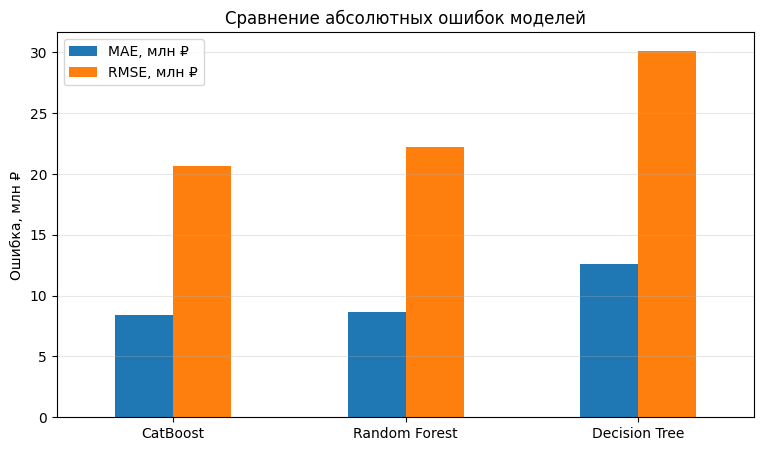

In [27]:
ax = comparison_display.set_index("Модель")[["MAE, млн ₽", "RMSE, млн ₽"]].plot(
    kind="bar",
    figsize=(9, 5),
    title="Сравнение абсолютных ошибок моделей"
)

ax.set_ylabel("Ошибка, млн ₽")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 9. График R²

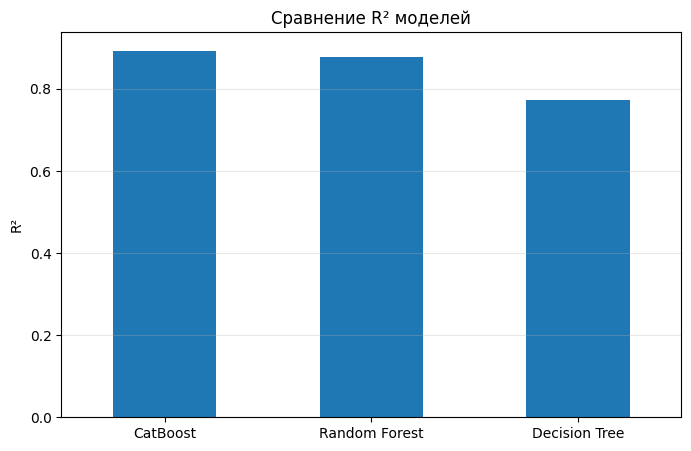

In [28]:
ax = comparison_display.set_index("Модель")[["R²"]].plot(
    kind="bar",
    figsize=(8, 5),
    title="Сравнение R² моделей",
    legend=False
)

ax.set_ylabel("R²")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 10. График процентной ошибки

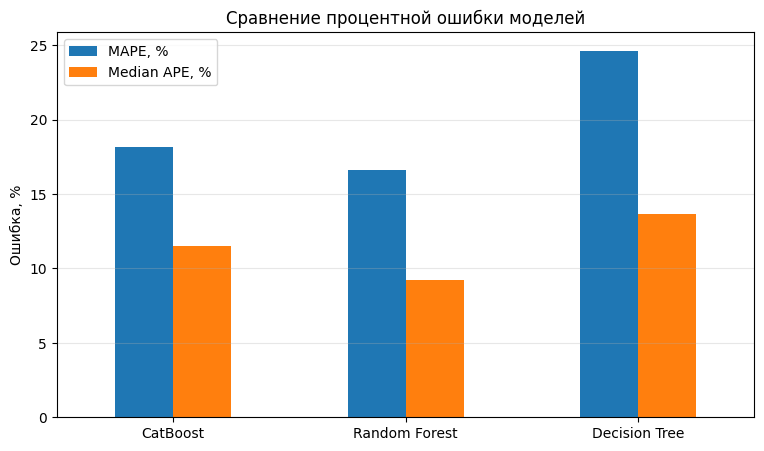

In [29]:
ax = comparison_display.set_index("Модель")[["MAPE, %", "Median APE, %"]].plot(
    kind="bar",
    figsize=(9, 5),
    title="Сравнение процентной ошибки моделей"
)

ax.set_ylabel("Ошибка, %")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 11. Факт vs прогноз

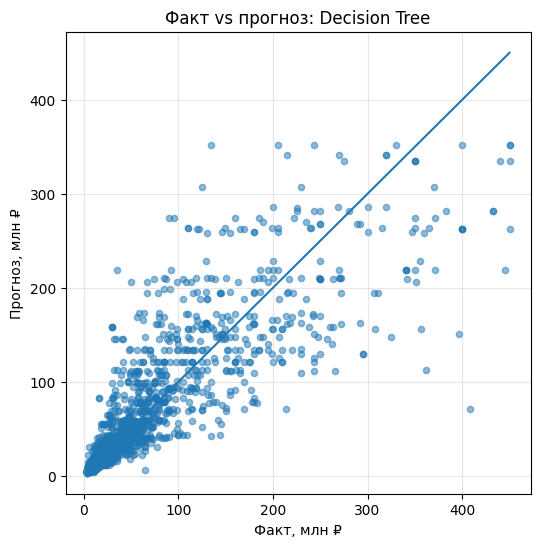

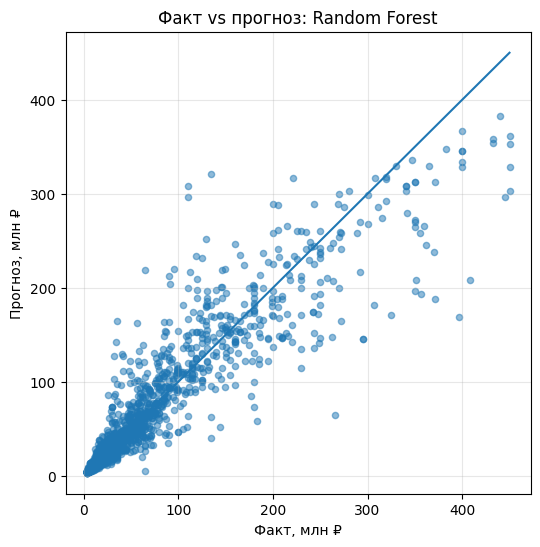

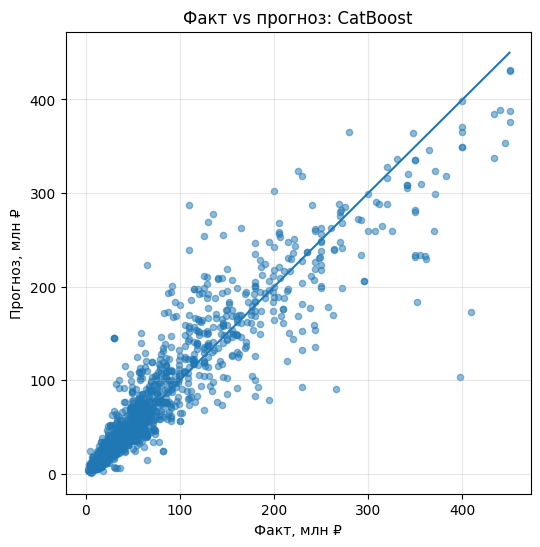

In [30]:
for name in predictions.keys():
    plot_df = pd.DataFrame({
        "Факт, млн ₽": y_test.values / 1_000_000,
        "Прогноз, млн ₽": predictions[name] / 1_000_000,
    })

    ax = plot_df.plot(
        x="Факт, млн ₽",
        y="Прогноз, млн ₽",
        kind="scatter",
        figsize=(6, 6),
        title=f"Факт vs прогноз: {name}",
        alpha=0.5
    )

    min_price = min(plot_df["Факт, млн ₽"].min(), plot_df["Прогноз, млн ₽"].min())
    max_price = max(plot_df["Факт, млн ₽"].max(), plot_df["Прогноз, млн ₽"].max())

    plt.plot([min_price, max_price], [min_price, max_price])
    plt.grid(alpha=0.3)
    plt.show()

## 12. Распределение абсолютной ошибки

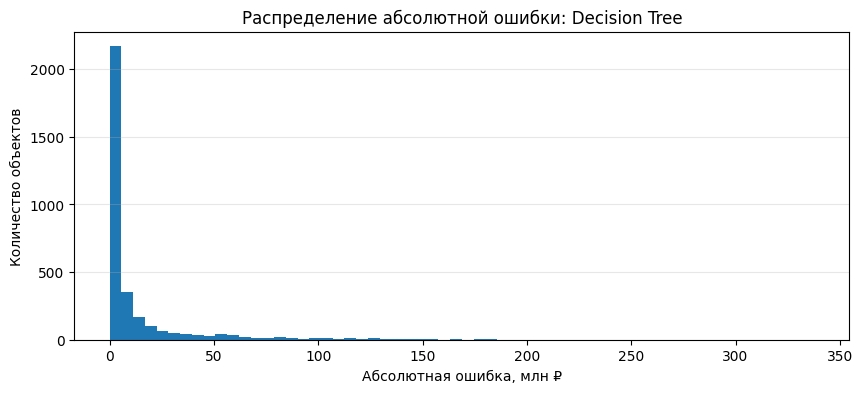

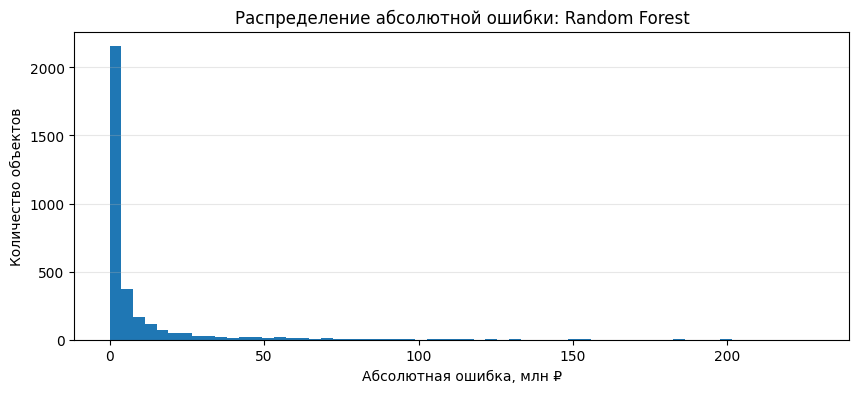

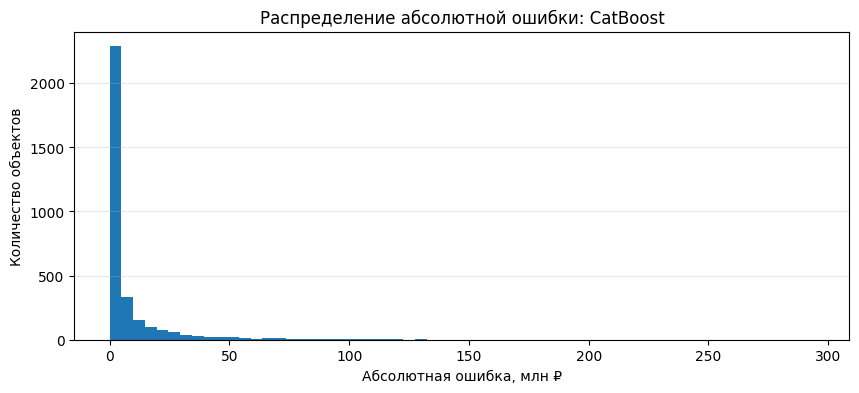

In [31]:
for name in predictions.keys():
    error_mln = predictions_df[f"{name}_abs_error"] / 1_000_000

    ax = error_mln.plot(
        kind="hist",
        bins=60,
        figsize=(10, 4),
        title=f"Распределение абсолютной ошибки: {name}"
    )

    ax.set_xlabel("Абсолютная ошибка, млн ₽")
    ax.set_ylabel("Количество объектов")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## 13. Примеры прогнозов

In [32]:
sample_cols = [
    "Price",
    "Apartment type",
    "Metro station",
    "Minutes to metro",
    "Number of rooms",
    "Area",
    "Living area",
    "Kitchen area",
    "Floor",
    "Number of floors",
    "Renovation",
]

sample_cols = [col for col in sample_cols if col in test_df.columns]

demo = test_df[sample_cols].copy().head(10)

for name in predictions.keys():
    demo[f"{name} prediction"] = predictions[name][:10]
    demo[f"{name} error"] = predictions[name][:10] - demo[TARGET].values

money_cols = [col for col in demo.columns if "Price" in col or "prediction" in col or "error" in col]
for col in money_cols:
    demo[col] = demo[col].round(0)

demo

,Price,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation,Decision Tree prediction,Decision Tree error,Random Forest prediction,Random Forest error,CatBoost prediction,CatBoost error
0,14200000.0,Secondary,Ботанический сад,16.0,2.0,51.0,36.0,8.0,17.0,17.0,Without renovation,14758144.0,558144.0,14399844.0,199844.0,14216560.0,16560.0
1,35000000.0,Secondary,Белорусская,16.0,3.0,70.0,52.0,17.0,5.0,6.0,Designer,22304000.0,-12696000.0,27259452.0,-7740548.0,52534401.0,17534401.0
2,120000000.0,Secondary,Третьяковская,6.0,4.0,121.0,14.9,16.7,3.0,7.0,Designer,107798576.0,-12201424.0,189674178.0,69674178.0,105452608.0,-14547392.0
3,15400000.0,Secondary,Давыдково,22.0,0.0,30.0,17.3,9.1,10.0,30.0,Designer,14030625.0,-1369375.0,15595308.0,195308.0,14029509.0,-1370491.0
4,7600000.0,Secondary,Авиамоторная,7.0,0.0,24.6,14.6,8.7,1.0,6.0,Cosmetic,6801399.0,-798601.0,5495497.0,-2104503.0,6931915.0,-668085.0
5,7716800.0,Secondary,Аминьевская,18.0,0.0,21.2,12.9,8.4,5.0,9.0,Cosmetic,8116713.0,399913.0,6861773.0,-855027.0,6847776.0,-869024.0
6,31000000.0,Secondary,Дмитровская,6.0,2.0,67.0,45.0,10.0,5.0,58.0,European-style renovation,34853466.0,3853466.0,31622064.0,622064.0,24851058.0,-6148942.0
7,11751468.0,New building,Сокольники,15.5,1.0,42.7,23.5,9.5,NaN,NaN,Unknown,8554193.0,-3197275.0,9793147.0,-1958321.0,6739343.0,-5012125.0
8,119000000.0,Secondary,Новослободская,8.0,4.0,200.0,15.0,23.2,7.0,8.0,European-style renovation,170499406.0,51499406.0,153340740.0,34340740.0,197685494.0,78685494.0
9,48500000.0,Secondary,Ростокино,13.0,3.0,143.3,101.8,33.7,39.0,58.0,Designer,134387602.0,85887602.0,75761466.0,27261466.0,61506274.0,13006274.0


## 14. Важность признаков

In [33]:
importance_files = {
    "Decision Tree": REPORTS_DIR / "decision_tree_feature_importance.csv",
    "Random Forest": REPORTS_DIR / "random_forest_feature_importance.csv",
    "CatBoost": REPORTS_DIR / "catboost_feature_importance.csv",
}

for name, path in importance_files.items():
    print(f"{name}: {path.exists()} | {path}")

Decision Tree: True | ..\reports\decision_tree_feature_importance.csv
Random Forest: True | ..\reports\random_forest_feature_importance.csv
CatBoost: True | ..\reports\catboost_feature_importance.csv


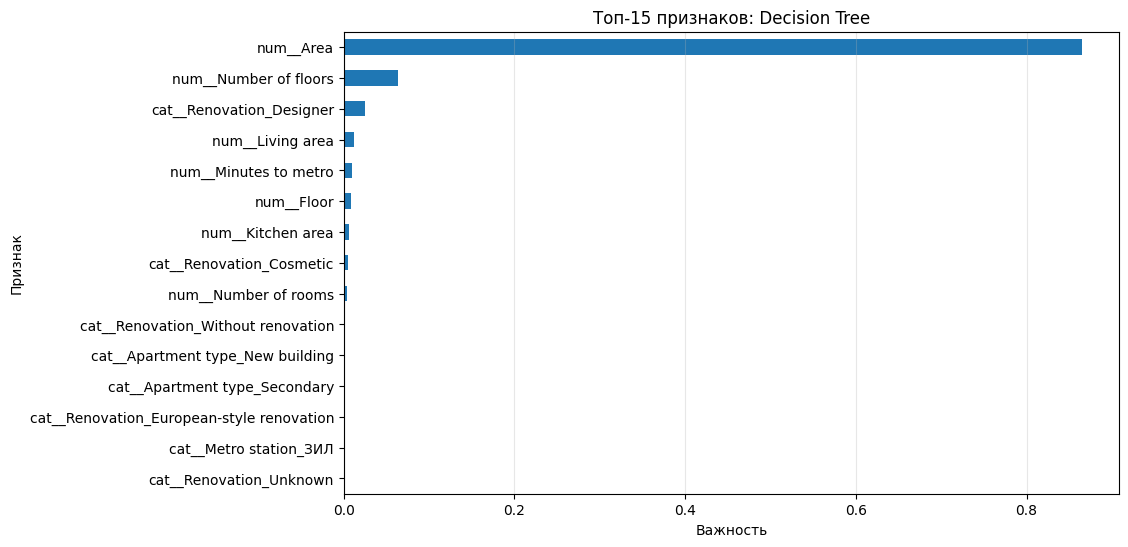

,feature,importance
0,num__Area,0.864742
1,num__Number of floors,0.063452
2,cat__Renovation_Designer,0.024491
3,num__Living area,0.012062
4,num__Minutes to metro,0.009433
5,num__Floor,0.007965
6,num__Kitchen area,0.006385
7,cat__Renovation_Cosmetic,0.004725
8,num__Number of rooms,0.004143
9,cat__Renovation_Without renovation,0.001309


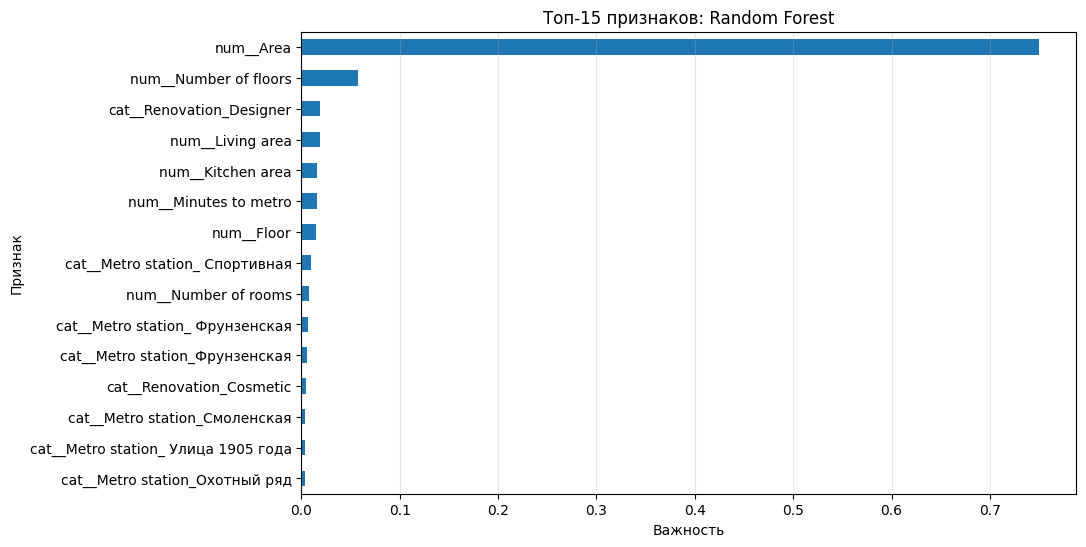

,feature,importance,original_feature
0,num__Area,0.750368,Area
1,num__Number of floors,0.057764,Number of floors
2,cat__Renovation_Designer,0.018873,Renovation
3,num__Living area,0.018775,Living area
4,num__Kitchen area,0.016260,Kitchen area
5,num__Minutes to metro,0.015448,Minutes to metro
6,num__Floor,0.014502,Floor
7,cat__Metro station_ Спортивная,0.009625,Metro station
8,num__Number of rooms,0.008067,Number of rooms
9,cat__Metro station_ Фрунзенская,0.006260,Metro station


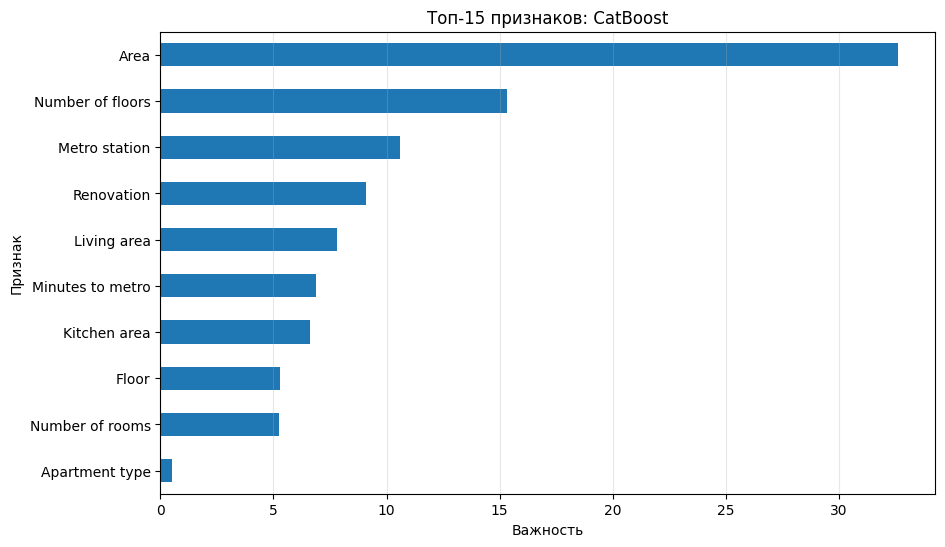

,feature,importance
0,Area,32.635079
1,Number of floors,15.314406
2,Metro station,10.612957
3,Renovation,9.077125
4,Living area,7.818157
5,Minutes to metro,6.860651
6,Kitchen area,6.619071
7,Floor,5.271525
8,Number of rooms,5.262103
9,Apartment type,0.528925


In [34]:
for name, path in importance_files.items():
    if not path.exists():
        continue

    importance_df = pd.read_csv(path)

    if "feature" not in importance_df.columns:
        possible_feature_cols = [c for c in importance_df.columns if "feature" in c.lower() or "признак" in c.lower()]
        if possible_feature_cols:
            importance_df = importance_df.rename(columns={possible_feature_cols[0]: "feature"})

    if "importance" not in importance_df.columns:
        possible_importance_cols = [c for c in importance_df.columns if "importance" in c.lower() or "важ" in c.lower()]
        if possible_importance_cols:
            importance_df = importance_df.rename(columns={possible_importance_cols[0]: "importance"})

    if {"feature", "importance"}.issubset(importance_df.columns):
        top = importance_df.sort_values("importance", ascending=False).head(15)

        ax = top.sort_values("importance").plot(
            x="feature",
            y="importance",
            kind="barh",
            figsize=(10, 6),
            title=f"Топ-15 признаков: {name}",
            legend=False
        )

        ax.set_xlabel("Важность")
        ax.set_ylabel("Признак")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

        display(top)

## 15. Итоговый вывод

In [35]:
best_by_mae = comparison.sort_values("MAE_mln").iloc[0]
best_by_r2 = comparison.sort_values("R2", ascending=False).iloc[0]
best_by_median_ape = comparison.sort_values("Median_APE").iloc[0]

print("Лучшая модель по MAE:", best_by_mae["Модель"], f'({best_by_mae["MAE_mln"]:.2f} млн ₽)')
print("Лучшая модель по R²:", best_by_r2["Модель"], f'({best_by_r2["R2"]:.3f})')
print("Лучшая модель по Median APE:", best_by_median_ape["Модель"], f'({best_by_median_ape["Median_APE"]:.2f}%)')

Лучшая модель по MAE: CatBoost (8.38 млн ₽)
Лучшая модель по R²: CatBoost (0.893)
Лучшая модель по Median APE: Random Forest (9.23%)
